# Import and utils

In [65]:
%reload_ext autoreload
%autoreload 2

import os
import random
import itertools
import multiprocessing as mp
from collections import Counter
from collections import defaultdict

import numpy as np
import json
import pandas as pd
import math
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import statsmodels.api as sm
import scipy.stats
import scipy.special as sc

import xgi
import networkx as nx
from networkx.algorithms import bipartite

from generator import node_addition_ho_fof, edge_addition_ho_fof, preferential_attachment, node_addition_ho_fof_resampled_T

# Load metrics result

In [66]:
def load_metrics(model, multiedges):
	df_metrics = pd.read_json(f'../out/metrics/{model}_metrics_multiedges_{multiedges}.json')
	return df_metrics
def process_columns(df_metrics):
	# convert M column to dict
	df_metrics['M'] = df_metrics['M'].apply(lambda x : {int(d): x[d] for d in x.keys()})
	df_metrics['M_key'] = df_metrics['M'].apply(lambda d: tuple(sorted(d.items())))
	# Compute average edge size per node
	df_metrics['avg_size'] = df_metrics['M'].apply(lambda M: sum(md*d for d, md in M.items())/sum(md for md in M.values()))
	y_bins = np.linspace(df_metrics['avg_size'].min(), df_metrics['avg_size'].max(), 15)
	df_metrics['avg_size_bin'] = pd.cut(df_metrics['avg_size'], bins=y_bins, include_lowest=True)
	# Compute pairwise_size
	df_metrics['pairwise_size'] = df_metrics['M'].apply(lambda M: sum([md * math.comb(d, 2) for d , md in M.items()]))
	# If overlap colum is a counter 
	if 'overlaps' in df_metrics.columns and df_metrics.dtypes['overlaps'] != 'float':
		df_metrics['overlaps'] = df_metrics['overlaps'].apply(lambda x : {int(d): x[d] for d in x.keys()})
		df_metrics['overlaps'] = df_metrics['overlaps'].apply(lambda x: sum(k * v for k, v in x.items()) / sum(x.values())) 



# Aggregated Network Analysis 

## Community structure and overlaps

In [85]:
from utils import plot_map_heatmap
label_map={
    'p': '$p$',
    'avg_size_bin' : r'$\overline{d}$',
    'pairwise_size' : r'$s_2$',
    'nb_clusters': 'number of clusters',
}
x = 'avg_size_bin'
y = 'pairwise_size'
col = None
row = None
col_wrap = 2

<Figure size 1200x800 with 0 Axes>

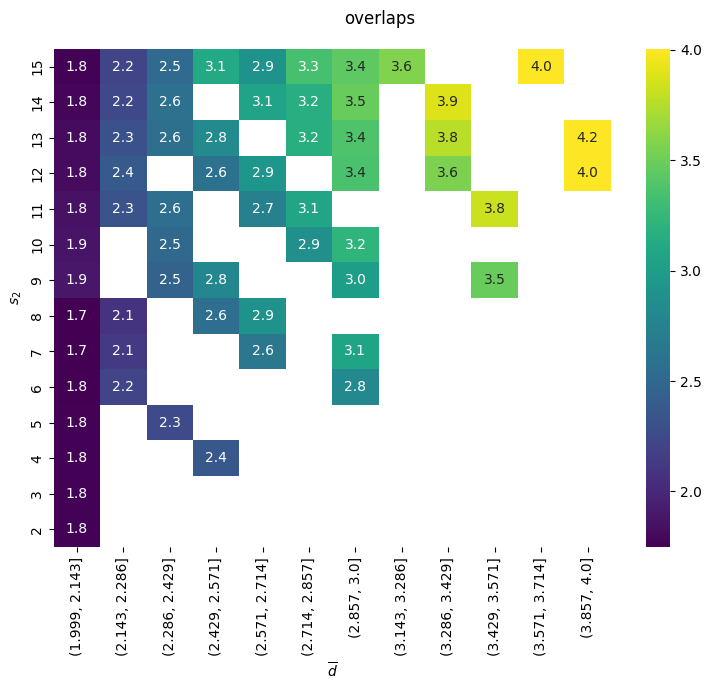

In [103]:
x = 'avg_size_bin'
y = 'pairwise_size'
feature = 'overlaps'
model = 'ho_fof'
multiedges= True
# Load
df_metrics = load_metrics(model, multiedges=multiedges )
#Process
process_columns(df_metrics)
df_metrics = df_metrics[df_metrics['n']==30000]


baseline = (
    df_metrics.loc[df_metrics['p'] == 0]
    .groupby('M_key')['overlaps']
    .mean()
)

df_metrics = df_metrics[df_metrics['p'] >0.9]

normalized = df_metrics['overlaps'] / df_metrics['M_key'].map(baseline)
df_metrics['overlaps'] = normalized

# plot
plt.figure(figsize=(12, 8)) 
plot_map_heatmap(df_metrics, feature, x, y, row, col, scale = 'quantile', col_wrap = col_wrap, agg_func = 'mean')
# plt.suptitle(f'{label_map.get(feature, feature)}', y=0.83)
plt.xlabel(label_map.get(x,x))
plt.ylabel(label_map.get(y,y))
plt.tight_layout()
plt.savefig(f'../out/Figures/{model}_{feature}_{x}_{y}.pdf')

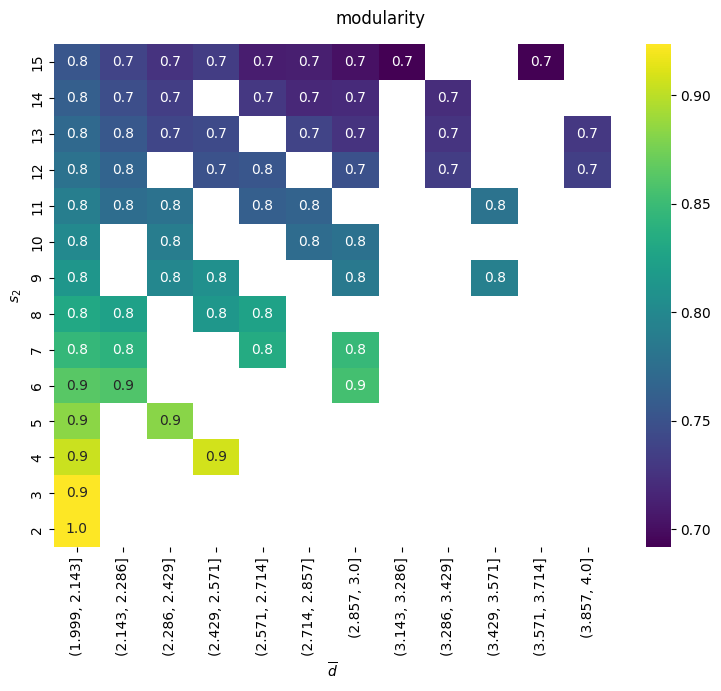

In [121]:
multiedges= True
# Load
df_metrics = load_metrics(model, multiedges= multiedges)

#Process
process_columns(df_metrics)
df_metrics = df_metrics[df_metrics['n']==30000]

# feature = 'nb_clusters'
feature = 'modularity'

model = 'ho_fof'

# x = 'p'

x = 'avg_size_bin'
df_metrics = df_metrics[df_metrics['p'] >0.9]

y = 'pairwise_size'


# plot
df = df_metrics.dropna(subset = feature)
plot_map_heatmap(df, feature, x, y, row, col, scale = 'quantile', col_wrap = col_wrap, agg_func = 'mean')
# plt.suptitle(f'{label_map.get(feature, feature)}', y=0.83)
plt.xlabel(label_map.get(x,x))
plt.ylabel(label_map.get(y,y))
plt.tight_layout()
plt.savefig(f'../out/Figures/{feature}_{x}_{y}.pdf')


## Rich club

In [200]:
import numpy as np
import pandas as pd
import networkx as nx
import xgi



n = 10_000

n0 =  20
p = 0.97
k0 = 1

Q = 30

Ms = [
    {2:7},
    {2:4,3:1},
    {2:1,3:2},
    {2:1,4:1}
]

metrics_path = f'../out/metrics/rc_n_{n}_p_{p}_n0_{n0}_k0_{k0}_Q_{Q}.json'
result = pd.read_json(metrics_path)

# Ensure M's keys are ints, and build a stable key for grouping/joins
result['M'] = result['M'].apply(lambda d: {int(k): v for k, v in d.items()})
result['M_key'] = result['M'].apply(lambda d: tuple(sorted(d.items())))


def explode_rc(df, col):
    tmp = df[['M_key','seed_M',col]].copy()
    tmp = tmp.assign(items=tmp[col].apply(lambda d: list(d.items()))).explode('items', ignore_index=True)
    tmp[['k', col]] = pd.DataFrame(tmp.pop('items').tolist(), columns=['k', col])
    tmp['k'] = tmp['k'].astype(int)
    tmp[col] = tmp[col].astype(float)
    return tmp

sur = explode_rc(result, 'rc')     # surrogates R
emp = explode_rc(result, 'rc_emp')   # empirical G (once per task; values will repeat across seed_swap)


# mean surrogate per (M_key, seed_M, k)
sur_mean = (sur
    .groupby(['M_key','seed_M','k'], as_index=False)['rc']
    .mean()
    .rename(columns={'rc':'rc_sur_mean'})
)

# empirical per (M_key, seed_M, k): take first occurrence
emp_first = (emp
    .drop_duplicates(['M_key','seed_M','k'])
    .rename(columns={'rc_g':'rc_emp'})
)

rc_df = sur_mean.merge(emp_first, on=['M_key','seed_M','k'], how='inner')
rc_df['rc_norm'] = rc_df['rc_emp'] / rc_df['rc_sur_mean']


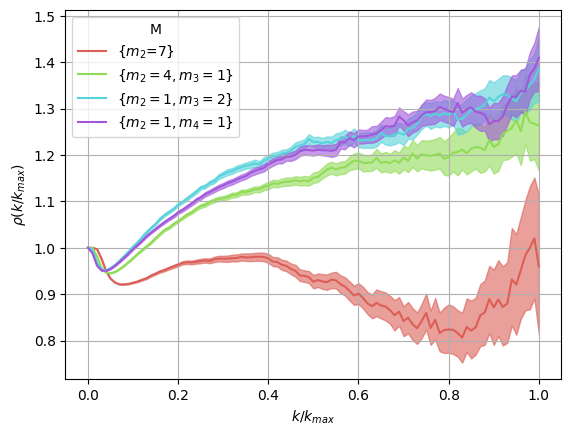

In [202]:

%matplotlib inline

label_map = {
    ((2, 7),): "{$m_2$=7}",
    ((2, 4), (3, 1)): "{$m_2=4,m_3=1$}",
    ((2, 1), (3, 2)): "{$m_2=1,m_3=2$}",
    ((2, 1), (4, 1)): "{$m_2=1,m_4=1$}",
}

def normalize_key(key):
    # e.g. [(2,7)] -> ((2,7),), [[2,7]] -> ((2,7),) etc.
    if isinstance(key, (list, tuple)):
        return tuple(tuple(x) if isinstance(x, (list, tuple)) else x for x in key)
    return key

rc_df['M_key_norm'] = rc_df['M_key'].apply(normalize_key)

# 3) Map safely (no reindexing), falling back to the original key as string if missing
rc_df['M_label'] = rc_df['M_key_norm'].apply(lambda k: label_map[k])

order_keys = [((2, 7),), ((2, 4), (3, 1)), ((2, 1), (3, 2)), ((2, 1), (4, 1))]
order_labels = [label_map[k] for k in order_keys]

rc_df['k'] = rc_df['k'] / rc_df.groupby(['M_label', 'seed_M'])['k'].transform('max')
rc_df['k'] = rc_df['k'].round(2)

palette = sns.color_palette("hls", n_colors=len(label_map))  # one color per p


ax = sns.lineplot(
    rc_df, x='k', y='rc_norm',
    hue='M_label', hue_order=order_labels,
    errorbar='ci', 
    err_style='band',         
    err_kws={'alpha': 0.6},palette = palette
    
)

ax.set_xlabel(r'$k/k_{max}$')
ax.set_ylabel(r'$\rho(k/k_{max})$')
ax.legend(title='M')



plt.grid()
plt.savefig(f'../out/Figures/rich_club.pdf')

In [ ]:
###### Try hypergraph rich club with mcmc configuration model as null model
from configuration_model import vertex_labeled_MH
M, seed_M, seed_swap= {3:1},1, 1
n= 10000
p=1
k0=1
n0=20
Q= 30
H = node_addition_ho_fof(n=n, M=M, p=p, k0=k0, n0=n0, seed = seed_M)
edges_input = H.edges.members()
# mcmc configuration model
E = H.num_edges
nswap = Q * E

MCMC_kwargs = {'edges': edges_input,
			'n_steps': nswap,
			'burnin_steps': 2 * nswap,
			'multiedges': True,
			'n_clash': 0,
			'seed':seed_swap,
			}

H_cm = xgi.Hypergraph(vertex_labeled_MH(**MCMC_kwargs))
# # compute rich club
# rc = rich_club(degree_count(H) )
# rc_emp = rich_club(degree_count(H_mc) )
# {"M": M, "seed_M": seed_M, "seed_swap":seed_swap, "rc": rc, 'rc_emp': rc_emp }

## Hypercore decomposition

In [123]:
# Load and process json file for core decomposition
n=10000
multiedges=True
df_core = pd.read_json(f'../out/metrics/core_n_{n}_multiedges_{multiedges}.json')
df_core['edge_size_counter'] = df_core['edge_size_counter'].apply(lambda x: Counter({int(k): int(v) for k , v in x.items()} ))
df_core['core'] = df_core['core'].apply(lambda core: { int(m) : {int(k) :  [set(component) for component in core[m][k]] for k, value in core[m].items() } for m in core.keys()})
df_core['M'] = df_core['M'].apply(lambda x :(tuple(tuple(val) for val in x)  ))


### Hypercoreness

### Hypercore size

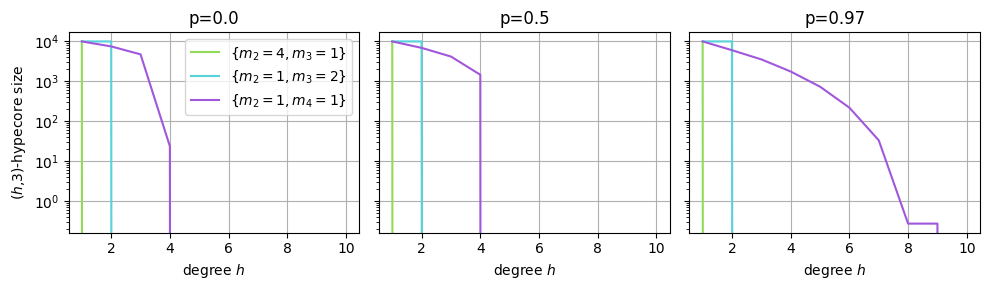

In [245]:
def canonicalize_2D_list(l: list):
	max_size = max(len(element) for element in l)
	for element in l:
		remaining = max_size - len(element)
		if remaining > 0 :
			element.extend([0]*remaining)
	return l
m = 3
label_map = {
    ((2, 7),): "{$m_2$=7}",
    ((2, 4), (3, 1)): "{$m_2=4,m_3=1$}",
    ((2, 1), (3, 2)): "{$m_2=1,m_3=2$}",
    ((2, 1), (4, 1)): "{$m_2=1,m_4=1$}",
}
fig, axs = plt.subplots(1,3, figsize = (10,3), sharey=True, sharex = True)
palette = sns.color_palette("hls", n_colors=len(label_map))  # one color per p

for p, ax in zip(df_core['p'].unique(), axs):
	for (M, label_M), c in zip(list(label_map.items())[m-2:], palette[m-2:]):
		core_size_M = []
		for core in df_core[(df_core['M'] == M) & (df_core['p'] == p) ]['core'] :
			core_size_k = []
			for k in core[m].keys():
				# take the largest connected component
				core_size_k.append(len(core[m][k][0]))
			# plot the 2 core (core_size_m[0] is the (k,2)-hypercore)
			core_size_M.append(core_size_k)
		canonicalize_2D_list(core_size_M)
		avg_core_size_M = np.mean(core_size_M, axis = 0)
		std_core_size_M = np.std(core_size_M, axis = 0)
		ax.plot(range(1, (len(avg_core_size_M)+2)), list(avg_core_size_M )+ [0], label = label_M, color = c)
		#ax.fill_between(range(1, (len(avg_core_size_M)+1)),avg_core_size_M + 2*std_core_size_M, avg_core_size_M - 2*std_core_size_M, alpha = 0.5)
	
	ax.set_title(f'p={p}')
	ax.set_xlabel(r'degree $h$')
	ax.grid()
	ax.set_yscale('log')
	# ax.set_xscale('log')

axs[0].legend()
axs[0].set_ylabel(fr'($h$,{m})-hypecore size')
plt.tight_layout()

plt.savefig(f'../out/Figures/{m}-core_size.pdf')


# Models compared to empirical

In [246]:
model = 'ho_fof_emp_ec'
multiedges = True
df_metrics = pd.read_json(f'../out/metrics/{model}_metrics_multiedges_{multiedges}.json')

### Generate random networks 

In [301]:
import itertools  
from metrics import gini, evolution_nb_nodes, degrees_t
from utils import get_param_from_emp, calibrate_from_emp, rescale_pnew, clean_edges

dataset = 'ec'
# Load empirical hypegraph
edges_emp = joblib.load(f'../data/edges_{dataset}.joblib')
np.random.shuffle(edges_emp)
edges_emp = clean_edges(edges_emp)
H_emp = xgi.Hypergraph(edges_emp)

# Get paramaters from emprical hypergraph
seed = 1
n0 = max(H_emp.size().values())
k0 = 1

D, P_new, t0 =  calibrate_from_emp(edges_emp, n0, shuffle = False, seed = seed)

# Generate polyadic closure model
p = 0.5

H_f = edge_addition_ho_fof(
    D = D,
    p = p,
    P_new = P_new,
    redirection = False,
    k0 = k0,
    n0 = n0,
    seed = seed
    )
    
# Generate preferential attachement
if dataset == 'village':    
    H_p = preferential_attachment(
        D = D,
        P_new = P_new,
        k0 = k0,
        n0 = n0,
        seed = seed
        )
elif dataset == 'ec':
    H_p = joblib.load(f'../out/simulations/preferential/H_p_{dataset}.joblib')



### Calibration verification

/tmp/ipykernel_13780/4169265261.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


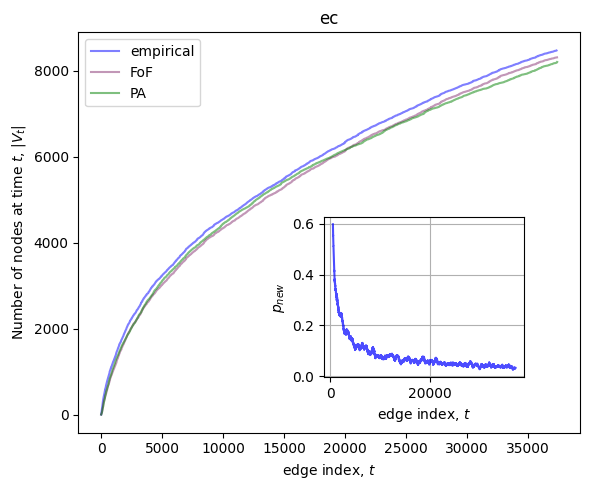

In [306]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(6,5))
results = [{'model': model, 'H': H} for model, H in zip(['empirical', 'FoF','PA', ],[H_emp, H_f, H_p])]
colors = [ 'blue', sns.color_palette("flare", n_colors= 3)[2],'green'] 

# Plot the main figure N_t
for result, c in zip(results, colors):
    label = result['model']
    H = result['H']
    edges = [list(e) for e in H.edges.members()]
    N_t = evolution_nb_nodes(edges, freq)
    ax.plot(range(0, len(N_t)*freq, freq), N_t, alpha=0.5, label=label, color=c)

ax.set_xlabel("edge index, $t$")
ax.set_ylabel("Number of nodes at time $t$, $|V_t|$")
# ax.grid()
ax.legend()
ax.set_title(f'{dataset}')

# Create an inset axes for p_new
inset_ax = inset_axes(ax, width="40%", height="40%", loc='lower right', borderpad=4)

# Plot the smoothed p_new on the inset

window_size = 500  # Adjust the window size as needed
P_new_smoothed = pd.Series(P_new).rolling(window=window_size).mean()
inset_ax.plot(range(len(P_new_smoothed)), P_new_smoothed, alpha=0.7, color='blue')
inset_ax.set_xlabel("edge index, $t$")
inset_ax.set_ylabel("$p_{new}$")
inset_ax.grid()

plt.tight_layout()
plt.savefig(f'../out/Figures/N_t_{dataset}.pdf', )
plt.show()

### Compute metrics 

In [249]:
# set results dataframe 
from metrics import clustering_metrics
results = [{'model': model, 'H': H} for model, H in zip(['empirical', 'FoF','PA'],[H_emp, H_f, H_p])]

## Overlaps and degree 

In [277]:
# Compute metrics for empirical graph 
from metrics import overlaps
from utils import clean_edges
from multiprocessing import Pool

dataset = 'village'
# Load empirical hypegraph
edges_emp = joblib.load(f'../data/edges_{dataset}.joblib')
np.random.shuffle(edges_emp)
edges_emp = clean_edges(edges_emp)
H_emp = xgi.Hypergraph(edges_emp)
# # Compute overlaps nb_it times
# nb_it = 100
# data = []
# for _ in range (nb_it) :
# 	data.append(overlaps(H_emp))
# df_metrics_emp = pd.DataFrame({'overlaps': data})
# #Compute clustering metrics
# for idx in df_metrics_emp.index:
# 	metrics = clustering_metrics(H_emp)
# 	df_metrics_emp.loc[idx, "modularity"] = metrics["modularity"]
# 	df_metrics_emp.loc[idx, "nb_clusters"] = metrics["nb_clusters"]
	
# # Save results in json file
# model = f'emp_{dataset}'
# multiedges = True
# df_metrics_emp['degree_count'] = [degree_count(H_emp) for _ in range(len(df_metrics_emp))]
# df_metrics_emp.to_json(f'../out/metrics/{model}_metrics_multiedges_{multiedges}.json')

In [278]:
# Load metrics

model = f'ho_fof_emp_{dataset}'
multiedges = True
df_metrics_fof = pd.read_json(f'../out/metrics/{model}_metrics_multiedges_{multiedges}.json')

model = f'preferential_emp_{dataset}'
multiedges = True
df_metrics_pa = pd.read_json(f'../out/metrics/{model}_metrics_multiedges_{multiedges}.json')

model = f'emp_{dataset}'
multiedges = True
df_metrics_emp = pd.read_json(f'../out/metrics/{model}_metrics_multiedges_{multiedges}.json')

for feature in ['overlaps', 'degree_count']:
	for df in [df_metrics_fof, df_metrics_pa, df_metrics_emp]:
		if feature in df.columns:
			df[feature] = df[feature].apply(lambda x : {int(d): x[d] for d in x.keys()})
		

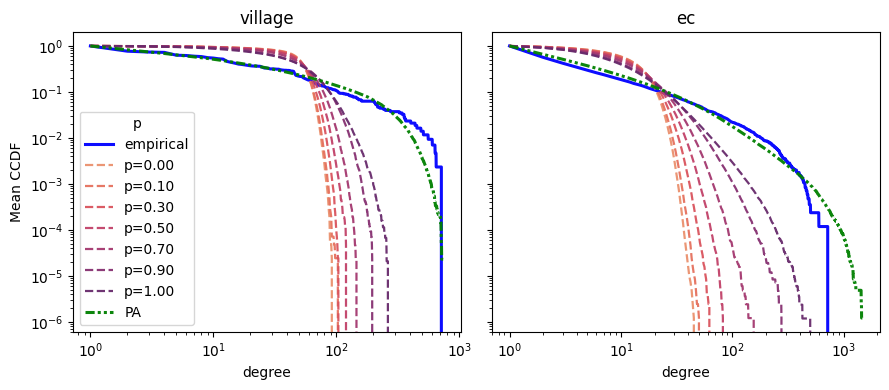

In [300]:
import numpy as np
import pandas as pd

def canonicalize(df, feature, k_max, k_min):
	df = df.copy()
	df[feature] = df.apply(
		lambda row: {k: c for k, c in row[feature].items() if k >= k_min and k<=k_max},
		axis=1
	)
	df[feature] = df.apply(
		lambda row: np.array([row[feature].get(k, 0) for k in range(k_min, k_max + 1)], dtype=float),
		axis=1
	)
	return df

def counts_to_ccdf(count_vec, eps=0.0):
    """
    count_vec is counts for k = k_min..k_max (already aligned).
    Returns CCDF over the same index: ccdf[i] = P(K >= k_i).
    """
    total = count_vec.sum()
    pmf = count_vec / total

    ccdf = np.cumsum(pmf[::-1])[::-1]
    return ccdf

def mean_ccdf_from_series_of_arrays(series_of_arrays):
    """
    series_of_arrays: a pandas Series where each entry is a 1D np.array of same length.
    """
    M = np.vstack(series_of_arrays.to_numpy())
    return M.mean(axis=0)

# Load metrics
def load_df_metrics(dataset):
	model = f'ho_fof_emp_{dataset}'
	multiedges = True
	df_metrics_fof = pd.read_json(f'../out/metrics/{model}_metrics_multiedges_{multiedges}.json')

	model = f'preferential_emp_{dataset}'
	multiedges = True
	df_metrics_pa = pd.read_json(f'../out/metrics/{model}_metrics_multiedges_{multiedges}.json')

	model = f'emp_{dataset}'
	multiedges = True
	df_metrics_emp = pd.read_json(f'../out/metrics/{model}_metrics_multiedges_{multiedges}.json')

	for feature in ['overlaps', 'degree_count']:
		for df in [df_metrics_fof, df_metrics_pa, df_metrics_emp]:
			if feature in df.columns:
				df[feature] = df[feature].apply(lambda x : {int(d): x[d] for d in x.keys()})
	return df_metrics_fof, df_metrics_pa, df_metrics_emp


fig, axs = plt.subplots(1,2, figsize=(9,4), sharey = True)
	# --- style definitions ---
style_emp = dict(color="blue", linestyle="-", linewidth=2.2, alpha=0.95)
style_pa  = dict(color="green", linestyle=(0, (3, 1, 1, 1, 1, 1)),  linewidth=2.2, alpha=0.95)
style_fof = dict(linestyle="--", linewidth=1.6, alpha=0.95)  # color set per p

for ax, dataset in zip(axs, ['village','ec']):
	df_metrics_fof, df_metrics_pa, df_metrics_emp = load_df_metrics(dataset)
	feature = 'degree_count'
	labels = {'degree_count':'degree', 'overlaps': 'overlap size'}
	feature_label = labels[feature]

	# ---- compute k_max, k_min as you do ----
	k_max_fof = max(df_metrics_fof.apply(lambda x: max(x[feature].keys()), axis=1))
	k_max_pa  = max(df_metrics_pa.apply(lambda x: max(x[feature].keys()), axis=1))
	k_max_emp = max(df_metrics_emp.apply(lambda x: max(x[feature].keys()), axis=1))
	k_max = max(k_max_fof, k_max_pa, k_max_emp)
	k_min = 1

	k = np.arange(k_min, k_max + 1)
	# ---- FOF: average CCDF within each p ----
	df_fof = canonicalize(df_metrics_fof, feature, k_max, k_min)
	df_fof['ccdf'] = df_fof[feature].apply(counts_to_ccdf)

	mean_ccdf_by_p = df_fof.groupby('p')['ccdf'].apply(mean_ccdf_from_series_of_arrays)
	# mean_ccdf_by_p.loc[p] is a vector aligned with k_values

	# ---- PA: average CCDF over simulations ----
	df_pa = canonicalize(df_metrics_pa, feature, k_max, k_min)
	df_pa['ccdf'] = df_pa[feature].apply(counts_to_ccdf)
	mean_ccdf_pa = mean_ccdf_from_series_of_arrays(df_pa['ccdf'])

	# ---- EMP: average CCDF over edge-sampling reps ----
	df_emp = canonicalize(df_metrics_emp, feature, k_max, k_min)
	df_emp['ccdf'] = df_emp[feature].apply(counts_to_ccdf)
	mean_ccdf_emp = mean_ccdf_from_series_of_arrays(df_emp['ccdf'])

	# --- empirical ---
	ax.plot(k, mean_ccdf_emp,label="empirical", **style_emp)

	# --- FOF: grouped by p with flare palette ---
	# Ensure stable order + matching number of colors
	ps = sorted(mean_ccdf_by_p.index)
	colors = sns.color_palette("flare", n_colors=len(ps))

	for c, p in zip(colors, ps):
		vec = mean_ccdf_by_p.loc[p]
		ax.plot(k, vec, color=c, label=f"p={p:.2f}", **style_fof)

	# --- PA ---
	ax.plot(k, mean_ccdf_pa,label="PA", **style_pa)

	ax.set_xlabel(feature_label)
	
	ax.set_yscale("log")
	ax.set_xscale("log")
	ax.set_title(f'{dataset}')

# Legend: keep p-lines under title "p", but still include empirical/PA
axs[0].legend(title="p")
axs[0].set_ylabel("Mean CCDF")
plt.tight_layout()
plt.savefig(f'../out/Figures/{feature}_emp.pdf')


/tmp/ipykernel_13780/369542517.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_13780/369542517.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, rotation=45, ha = 'right')


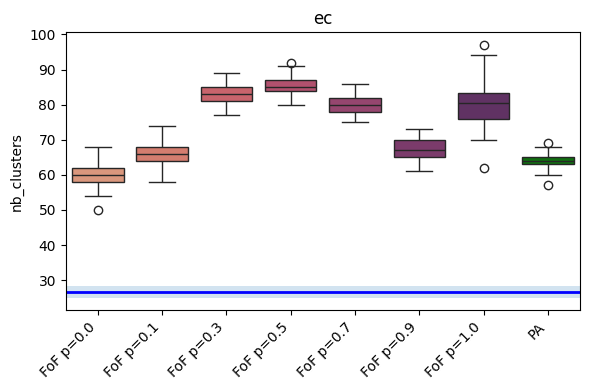

In [271]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metric = "nb_clusters"

# empirical summary
emp_mean = df_metrics_emp[metric].mean()
emp_std  = df_metrics_emp[metric].std(ddof=1)
# --- ordered p values
ps = sorted(df_metrics_fof["p"].unique())

# --- build combined dataframe with a single categorical x
df_fof = df_metrics_fof.copy()
df_fof["category"] = df_fof["p"].map(lambda p: f"FoF p={p:.1f}")

df_pa = df_metrics_pa.copy()
df_pa["category"] = "PA"

df_all = pd.concat(
    [df_fof[["category", metric]], df_pa[["category", metric]]],
    ignore_index=True
)

# --- category order: FoF in ordered p, then PA
order = [f"FoF p={p:.1f}" for p in ps] + ["PA"]

# --- colors: flare for FoF, green for PA
fof_colors = sns.color_palette("flare", n_colors=len(ps))
palette = {f"FoF p={p:.1f}": c for p, c in zip(ps, fof_colors)}
palette["PA"] = "green"

plt.figure(figsize=(6, 4))
ax = sns.boxplot(
    data=df_all, x="category", y=metric,
    order=order,
    palette=palette
)

# empirical mean + std band (and dashed boundaries)
ax.axhline(emp_mean, linewidth=2, color = 'blue')
ax.axhspan(emp_mean - emp_std, emp_mean + emp_std, alpha=0.2)


# --- pretty x tick labels: keep "PA", format FoF p with 1 decimal
tick_labels = [f"FoF p={p:.1f}" for p in ps] + ["PA"]  # or keep "FoF p=..." if you prefer
ax.set_xticklabels(tick_labels, rotation=45, ha = 'right')
ax.set_title(f'{dataset}')
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(f'../out/Figures/{dataset}_{metric}.pdf')


## Order Overlaps 

In [53]:
def intersection_profil(edges):
	max_size = max( len(e) for e in edges) 
	r = np.full((max_size+1 , max_size+1) , None)

	for e1, e2 in itertools.combinations(edges, 2):
		size_1 = len(e1)
		size_2 = len(e2)
		intersection_size = len(e1 & e2)
		if r[size_1,size_2] == None:
			r[size_1,size_2]= [intersection_size]
			r[size_2,size_1]= [intersection_size]
		else:
			r[size_1,size_2].append(intersection_size)
			r[size_2,size_1].append(intersection_size)
	r = np.array([
		[
			0 if cell is None else np.mean(cell)
			for cell in row
		]
		for row in r
	], dtype=float)
	return r


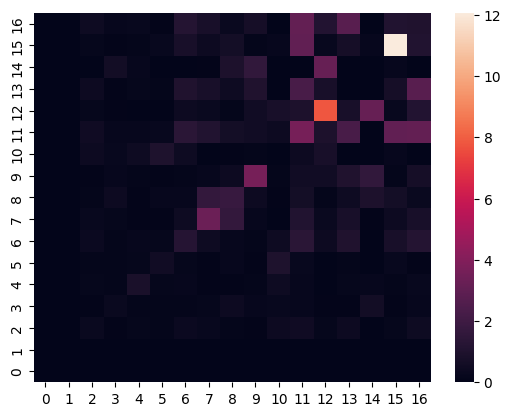

In [146]:
from utils import clean_edges
dataset = 'village'
# Load empirical hypegraph
edges_emp = joblib.load(f'../data/edges_{dataset}.joblib')
np.random.shuffle(edges_emp)
edges_emp = clean_edges(edges_emp)
edges_emp = [ e for e in edges_emp if len(e) < 20]
H_emp = xgi.Hypergraph(edges_emp)

# Chodrow intersection profile
edges = np.random.choice(H_emp.edges.members(), 5000)
r_emp = intersection_profil(edges)
ax = sns.heatmap(r)
ax.invert_yaxis()

In [147]:
dataset = 'village'
directory = f'../out/simulations/mcmc_{dataset}'
rs = []
for file in os.listdir(directory):
	# Load empirical hypegraph
	H = joblib.load(os.path.join(directory, file))['H']
	edges_emp = H.edges.members()
	edges_emp = [ e for e in edges_emp if len(e) < 20]
	H_emp = xgi.Hypergraph(edges_emp)

	# Chodrow intersection profile
	edges = np.random.choice(H_emp.edges.members(), 5000)
	rs.append(intersection_profil(edges))


In [148]:
# largest dimension
max_size = max(r.shape[0] for r in rs)

# pad all matrices to max_size x max_size
padded = [
    np.pad(
        r,
        ((0, max_size - r.shape[0]),
         (0, max_size - r.shape[1])),
        mode='constant'
    )
    for r in rs
]

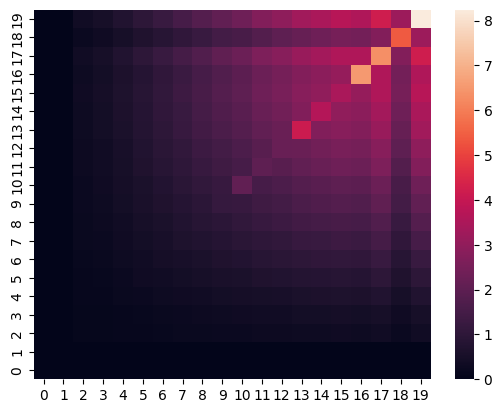

In [149]:
avg_r = np.mean(padded,axis = 0)
ax = sns.heatmap(avg_r)
ax.invert_yaxis()

/tmp/ipykernel_46537/3383259053.py:3: RuntimeWarning: invalid value encountered in divide
  ax = sns.heatmap(np.log(r_/avg_r))
/tmp/ipykernel_46537/3383259053.py:3: RuntimeWarning: divide by zero encountered in log
  ax = sns.heatmap(np.log(r_/avg_r))


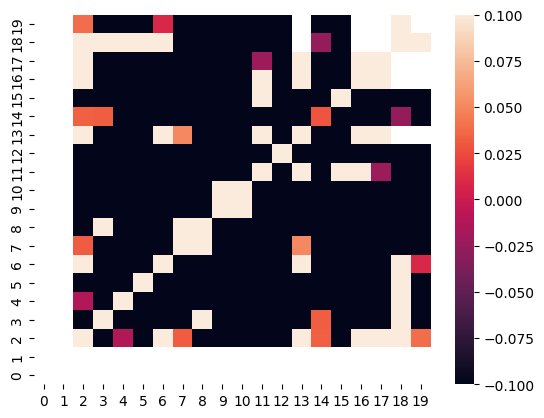

In [154]:
r_ = np.pad(r_emp, ((0, avg_r.shape[0] - r_emp.shape[0]),
         (0, avg_r.shape[1] - r_emp.shape[1])), mode='constant')
ax = sns.heatmap(np.log(r_/avg_r))
ax.invert_yaxis()

## Node overlaping metric Malizia

In [6]:
# Malizia paper
def intra_order_overlap(triangles_list):
    """
    Function to calculate both local and global intra-order hyperedge overlap.

    Parameters
    -----
    N : int
      Number of nodes
    triangles_list : ndarray
      Array with a list of 2-hyperedges in the form [(0,1,2),(2,3,4),...etc] 
      Note that, the indices of the nodes must be continuous from 0 to N-1.
    
    Output
    -----
    global_intra_order_overlap : float64
      Value of global intra-order overlap
    local_intra_order_overlap : ndarray
      Array with the values of intra-order overlap of each node.
    
    """
    N = len(np.unique(triangles_list))
    list_k2_nodes = np.zeros(N, dtype=np.float64)  
    for a, b, c in triangles_list:
        list_k2_nodes[a] += 1
        list_k2_nodes[b] += 1
        list_k2_nodes[c] += 1
    
    local_intra_order_overlap = np.zeros(N, dtype=np.float64)
    
    for i in range(N):
        k2 = int(list_k2_nodes[i])  
        if k2 <= 1:
            continue
        
        max_cardinality = 2 * k2 + 1
        min_cardinality = np.ceil((3 + np.sqrt(1 + 8 * k2)) / 2)
        
        union_set = set()
        for triple in triangles_list:
            if i in triple:
                union_set.update(triple)
        
        union_cardinality = len(union_set)
        local_intra_order_overlap[i] = 1 - (union_cardinality - min_cardinality) / (max_cardinality - min_cardinality)    
    
    global_intra_order_overlap = np.dot(local_intra_order_overlap, list_k2_nodes.astype(np.float64)) / np.sum(list_k2_nodes)
    
    return global_intra_order_overlap,local_intra_order_overlap
triangles_list = ([0,1,2],[0,1,3])
intra_order_overlap(triangles_list)

(np.float64(0.6666666666666666), array([1., 1., 0., 0.]))

# Graph vizualisation

In [294]:
from utils import get_param_from_emp

# Load empirical hypegraph
edges_emp = joblib.load('../data/edges_ec.joblib')
H_emp = xgi.Hypergraph(edges_emp)
# Get paramaters from emprical hypergraph

n0 = max(H_emp.size().values())
k0 = 1
D, P_new, t0 =  calibrate_from_emp(edges_emp, n0, shuffle = False, seed = seed)

p = 0.99
k0 = 1
n0 = None
seed = 1

H = edge_addition_ho_fof(
    D = D,
    p = p,
    P_new = P_new,
    k0 = k0,
    n0 = n0,
    seed = seed)

In [240]:
import itertools
n = 2_000

n0 =  20
p = 0.97
k0 = 1
seed = 10



In [ ]:
M = {2:2}
H1 = node_addition_ho_fof(
    n=n,
    M=M,
    p=p, 
    k0 = k0,
    n0 = n0,
    seed = seed)

In [ ]:
M = {2:7}
H1 = node_addition_ho_fof(
    n=n,
    M=M,
    p=p, 
    k0 = k0,
    n0 = n0,
    seed = seed)


In [248]:

M = {2: 1, 3: 2}
H = node_addition_ho_fof(
    n=n,
    M=M,
    p=p, 
    n0 = n0,
    seed = seed)



In [249]:
from utils import XGI_2_nxBipartite
import networkx as nx

# H = H_f.copy()
#H.cleanup(relabel = False, multiedges = True)
B = XGI_2_nxBipartite(H)
edges= H.edges.members()
step = 1
nodes_seen = set()
all_future_nodes = [set(edge) for edge in edges]
    
# for t, edge in enumerate(tqdm(H.edges)):
#     start_time = t * step
#     end_time = start_time + step
    
#     # Assign times to hyperedge node
#     B.nodes[edge]['start'] = start_time
#     # B.nodes[edge]['end'] = end_time

#     current_nodes = set(edges[t])
#     new_nodes = current_nodes - nodes_seen

#     # Dead nodes = previously seen nodes that do not appear in any future edges
#     future_nodes = set().union(*all_future_nodes[t+1:])
#     dead_nodes = nodes_seen - future_nodes

#     # Assign timestamps
#     for node in new_nodes:
#         B.nodes[node]['start'] = start_time
#     # for node in dead_nodes:
#     #     if 'end' not in B.nodes[node]:  # Avoid overwriting if already set
#     #         B.nodes[node]['end'] = start_time
#     nodes_seen.update(current_nodes)

nx.write_gexf(B, "../out/graph_viz/H.gexf")

In [ ]:
from metrics import core_decomposition, hypercoreness
from utils import XGI_2_nxBipartite

# def g_m(x):
# 	return {m : sum(x.get(m_tild, 0) for m_tild in range(m, max(x.keys())+1))/ sum(x.values()) for m in range(2, int(max(x.keys())+1))}

def g_m(x):
	return {m : x.get(m, 0)/ sum(x.values()) for m in range(2, int(max(x.keys())+1))}

n = 10000
k0 = 1
n0= 20
Ms = [
    {2:7},
    {2:4,3:1},
    {2:1,3:2},
    {2:1,4:1}
]
ps = [0.97]
labels = {
    "{$m_2$=7}",
    "{$m_2=4,m_3=1$}",
    "{$m_2=1,m_3=2$}",
    "{$m_2=1,m_4=1$}",
}
for M, label in zip(Ms, labels):
	for p in ps:
		H = node_addition_ho_fof(n=n, M=M, p=p, k0=k0, n0=n0)
		core, _ = core_decomposition(H, multiedges= False)
		cent = hypercoreness(core, g_m(Counter(H.edges.size.asdict().values())) )
		B = XGI_2_nxBipartite(H)
		nx.set_node_attributes(B, cent, 'hypercoreness')
		nx.write_gexf(B, f'../out/graph_viz/hypercoreness_H_{M}_p_{p}_gm_frac.gexf')


100%|██████████| 2/2 [61:35:26<00:00, 110863.40s/it]   


edge size = 3, requested size  =4
edge size = 3, requested size  =4
edge size = 3, requested size  =4


  0%|          | 0/3 [00:00<?, ?it/s]

# Analytical solutions

## Estimation of $\Theta_i$

In [136]:
def fit_powerlaw_log_ols(h, Theta):
    x = np.log(h)
    y = np.log(Theta)
    theta, logc = np.polyfit(x, y, 1)
    #R2
    yhat = theta * x + logc
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    c = float(np.exp(logc))
    return c, float(theta), float(r2)


In [137]:
def load_h(directory, filename):
    path = os.path.join(directory, filename)
    data = joblib.load(path)
    H = data['hypergraph']
    params = data.get('params', {})
    return H, params

In [139]:
metrics = []
directory = '../out/simulations/ho_fof'
all_files = [f for f in os.listdir(directory) if f.endswith(".joblib") and 'n-100000' in f and 'p-0.97' not in f ]


In [ ]:
metrics = []
directory = '../out/simulations/ho_fof'
all_files = [f for f in os.listdir(directory) if f.endswith(".joblib") and 'n-100000' in f and 'p-0.97' not in f ]
for filename in tqdm(all_files):
    # build hypergraph
    H, params = load_h(directory, filename)
    p = params['p']
    M = params['M']
    s = list(M.keys())[0] -1
    seed = params ['seed']


    # H-degrees
    nodes = list(H.nodes)
    deg =np.fromiter(H.degree().values(), dtype = int)
    h_emp, counts = np.unique(deg.astype(int), return_counts = True)
    
    # --- Measure Theta
    G = xgi.to_graph(H)
    g_deg = np.fromiter(dict(G.degree()).values(), dtype = float)
    A = nx.to_scipy_sparse_array(G, nodelist=nodes, dtype=float, format='csr')
    invdeg = np.zeros_like(g_deg) 
    np.divide(1.0, g_deg+1, out=invdeg)  # 0 for deg==0
    theta = (invdeg + A @ invdeg)*p  # theta_v =  1/(g_deg(v)+1)* + sum_{j in N(i)} 1/(g_deg(v)+1)
    # --- Theta vs h
    df = pd.DataFrame({"h_i": deg.astype(int), "theta_i": theta, 'k_i': g_deg })
    gb = df.groupby("h_i", sort=True)["theta_i"].mean()

    h = np.array(gb.index)
    Theta = np.array(gb)
    c, theta, r2= fit_powerlaw_log_ols(h, Theta)
    theory = c*h**theta

    metrics.extend([{'s': s,
                        'p':p,
                        'seed': seed,
                        'theta': theta,
                        'c': c,
                        'h_i': h_i,
                        'degree_counts': counts_h,
                        'Theta': Theta_h,
                        'Theta_theory': theory_h
                        } for h_i, counts_h, Theta_h, theory_h in zip(h, counts, Theta, theory)])

metrics_add = pd.DataFrame(metrics)
#metrics.to_csv('../out/metrics/degree_dist_metrics.csv')



In [142]:
metrics = pd.read_csv('../out/metrics/degree_dist_metrics.csv')
#metrics = metrics[metrics['p'] != 0.97]
#metrics = metrics[metrics['p'] != 1]

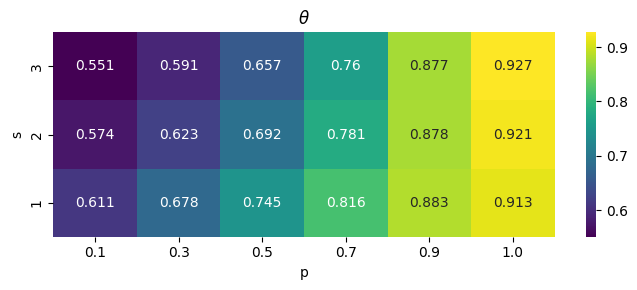

In [143]:
fig, ax = plt.subplots(figsize = (7,3))
theta_df = pd.pivot_table(metrics, values= 'theta', index = 's', columns = 'p', aggfunc = 'mean',)

ax = sns.heatmap(theta_df,  cmap="viridis", annot = True ,  fmt = '.3')
ax.invert_yaxis()

# fig, ax = plt.subplots()

# theta_df = pd.pivot_table(metrics, values= 'theta', index = 's', columns = 'p', aggfunc = 'sem',)
# ax = sns.heatmap(theta_df,  cmap="viridis", annot = True)

ax.set_title(r'$\theta$')
plt.tight_layout()
plt.savefig('../out/Figures/theta_vs_sp.pdf')

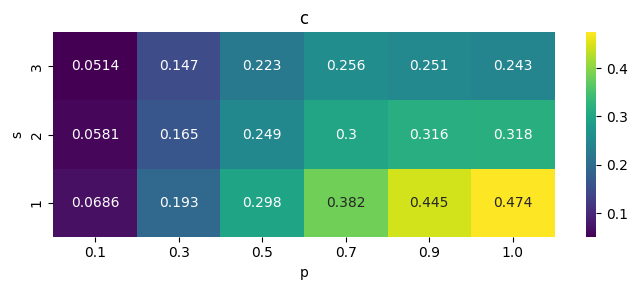

In [144]:
fig, ax = plt.subplots(figsize = (7,3))
c_df = pd.pivot_table(metrics, values= 'c', index = 's', columns = 'p', aggfunc = 'mean',)
ax = sns.heatmap(c_df,  cmap="viridis", annot = True ,  fmt = '.3')
ax.set_title(r'c')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../out/Figures/c_vs_sp.pdf')

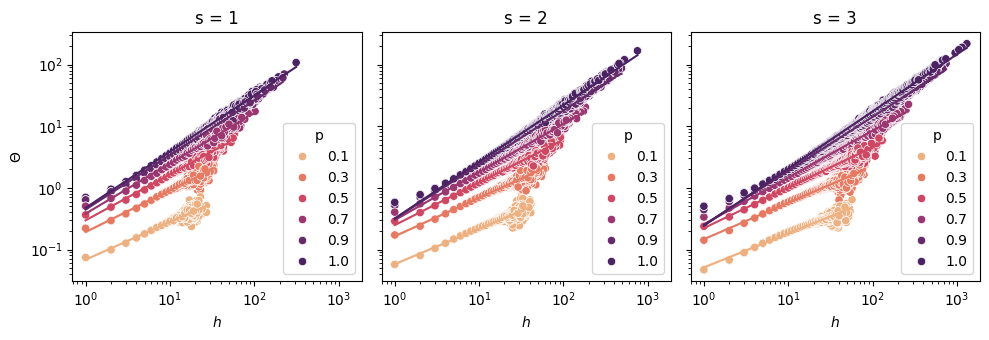

In [308]:
fig, axs =plt.subplots(1,3, figsize = (10,3.5), sharex = True, sharey= True)

for ax, s in zip(axs, np.sort(metrics['s'].unique())):
    fitted_param = metrics[metrics['s'] == s]
    sns.scatterplot(fitted_param, x = 'h_i', y = 'Theta', hue='p', ax =ax, palette = 'flare')
    sns.lineplot( fitted_param, x ='h_i', y='Theta_theory', hue = 'p', errorbar= 'se', ax =ax, legend = None, palette = 'flare')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$h$')
    ax.set_ylabel(r'$\Theta$')
    ax.set_title(f's = {s}')
plt.tight_layout()

plt.savefig(f'../out/Figures/Theta_s.png')



/tmp/ipykernel_13780/3539576895.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_fill_one_run))


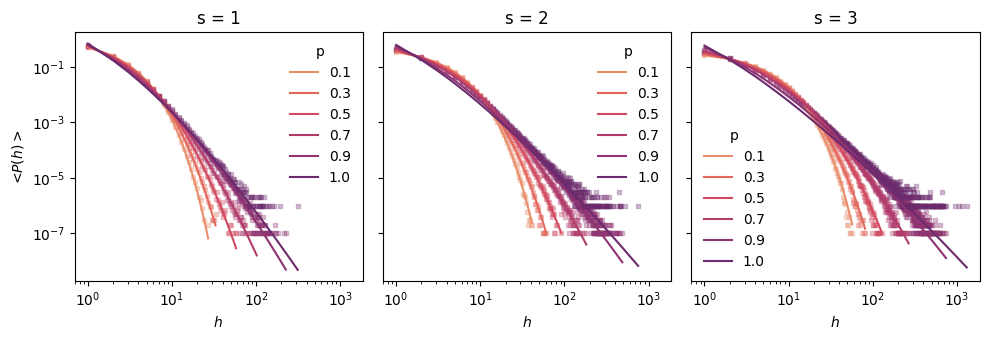

In [309]:
# Degree distribution
from scipy import stats
import time

hmax = metrics.groupby(['s','p'])['h_i'].max()

def _fill_one_run(g):
    s, p, run = g.name
    _h_max = int(hmax.loc[(s, p)])
    # make a full index 1..H and fill missing h with 0
    filled = (g.set_index('h_i')['degree_counts']
                .reindex(range(1, _h_max + 1), fill_value=0)
                .rename_axis('h_i')
                .reset_index())
    filled['s'], filled['p'], filled['seed'] = s, p, run
    return filled

filled_counts = (metrics
                 .groupby(['s','p', 'seed'], group_keys=False)
                 .apply(_fill_one_run))


ps = np.sort(metrics['p'].unique())

palette = sns.color_palette("flare", n_colors=len(ps))  # one color per p
color_dict = dict(zip(sorted(ps), palette))  # map each p to a color

fig, axs = plt.subplots(1,3,figsize =(10,3.5), sharex= True, sharey = True)
for ax, s in zip( axs, np.sort(metrics['s'].unique())):
    
    for p in ps:
        avg = filled_counts.groupby(['s', 'p', 'h_i'] )['degree_counts'].mean().loc[s,p] # get the mean degree distribution 
        h_emp, counts = avg.index, avg
        pmf = counts / counts.sum()

        color = color_dict[p]
        ax.scatter(h_emp, pmf, alpha = 0.3, marker= 's', s = 10, color = color)
        # ----- Theory results
        # Get c and theta 
        theta = metrics[(metrics['s'] == s) & (metrics['p'] == p)]['theta'].mean() 
        #theta = 1
        c = metrics[(metrics['s'] == s) & (metrics['p'] == p)]['c'].mean()
        
        # Compute P
        h = np.arange(1,h_emp.max() +1)
                             
        alpha_h = (s*(1-p)+s*c*h**theta)
        P_prod = 1/alpha_h * np.cumprod(alpha_h/(1+alpha_h))
        
        ax.plot(h, P_prod, label= p, color =color)

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r"$h$ ")
    ax.legend(title="p", frameon=False)
    ax.set_title(f's = {s}')
axs[0].set_ylabel(r"<$P(h)>$")
plt.tight_layout()
plt.savefig(f'../out/Figures/degree_dist_s.pdf')



/tmp/ipykernel_228784/3275647454.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_fill_one_run))


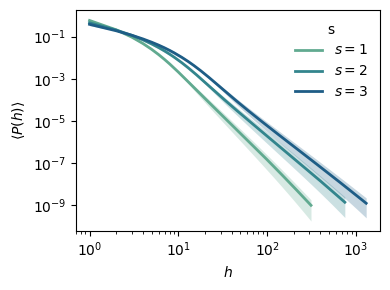

In [62]:
BAND = "se"        # options: "std", "se", "quantile"
BAND_SCALE = 1.0   # use 1.96 for ~95% normal CI when BAND="se" or "std"
EPS = 1e-12

def _fill_one_run(g):
    s, p, run = g.name
    _h_max = int(hmax.loc[(s, p)])
    # make a full index 1..H and fill missing h with 0
    filled = (g.set_index('h_i')['degree_counts']
                .reindex(range(1, _h_max + 1), fill_value=0)
                .rename_axis('h_i')
                .reset_index())
    filled['s'], filled['p'], filled['seed'] = s, p, run
    return filled

    
ss = np.sort(metrics['s'].unique())
fig, ax = plt.subplots(figsize = (4,3))
palette = sns.color_palette("crest", n_colors=len(ss))  # one color per p
color_dict = dict(zip(sorted(ss), palette))  # map each p to a color
filled_counts = (metrics
                 .groupby(['s','p', 'seed'], group_keys=False)
                 .apply(_fill_one_run))

                 
for i, s in enumerate(ss):
    color = color_dict[s]

    # h grid: use empirical max h for this s (or set your own Hmax)
    counts_by_h = (filled_counts[filled_counts['s'] == s]
                   .groupby('h_i')['degree_counts']
                   .mean())
    h = np.arange(1, counts_by_h.index.max() + 1)

    # collect theory curves across simulations/ps for this s
    ps_for_s = np.sort(metrics.loc[metrics['s'] == s, 'p'].unique())
    curves = []
    for p in ps_for_s:
        theta_sp = metrics[(metrics['s'] == s) & (metrics['p'] == p)]['theta'].mean()
        c_sp     = metrics[(metrics['s'] == s) & (metrics['p'] == p)]['c'].mean()
        alpha_h  = (s * (1 - p) + s * c_sp * h**theta_sp)
        P_prod   = (1 / alpha_h) * np.cumprod(alpha_h / (1 + alpha_h))
        curves.append(P_prod)

    M = np.vstack(curves)  # shape: (n_sims, len(h))

    # center line = mean
    mean_P = M.mean(axis=0)

    # band = std or quantiles
    if BAND == "std":
        spread = M.std(axis=0, ddof=1) if M.shape[0] > 1 else np.zeros_like(mean_P)
        lower = np.maximum(mean_P - spread, EPS)
        upper = np.maximum(mean_P + spread, EPS)
    elif BAND == "quantile":
        lower = np.quantile(M, 0.05, axis=0)
        upper = np.quantile(M, 0.95, axis=0)
        lower = np.maximum(lower, EPS)
        upper = np.maximum(upper, EPS)
    elif BAND == "se":
        # per-h sample size in case some runs have NaN/missing points
        n_eff = np.sum(~np.isnan(M), axis=0).astype(float)
        std = np.nanstd(M, axis=0, ddof=1)  # ddof=1 for unbiased if n_eff>1
        se = np.where(n_eff > 0, std / np.sqrt(n_eff), 0.0)
        spread = BAND_SCALE * se
        lower, upper = mean_P - spread, mean_P + spread
        # Tip: set BAND_SCALE=1.96 for ~95% CI under normality
    else:
        raise ValueError("BAND must be 'std' or 'quantile'")

    # plot mean + shaded band
    ax.plot(h, mean_P, color=color, lw=2, label=fr"$s={s}$")
    ax.fill_between(h, lower, upper, color=color, alpha=0.25, linewidth=0)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r"$h$")
ax.set_ylabel(r"$\langle P(h)\rangle$")
ax.legend(title="s", frameon=False)
plt.tight_layout()
plt.savefig('../out/Figures/degree_dist_band_over_p_all_s.pdf')


## Degree vs number of neighbors

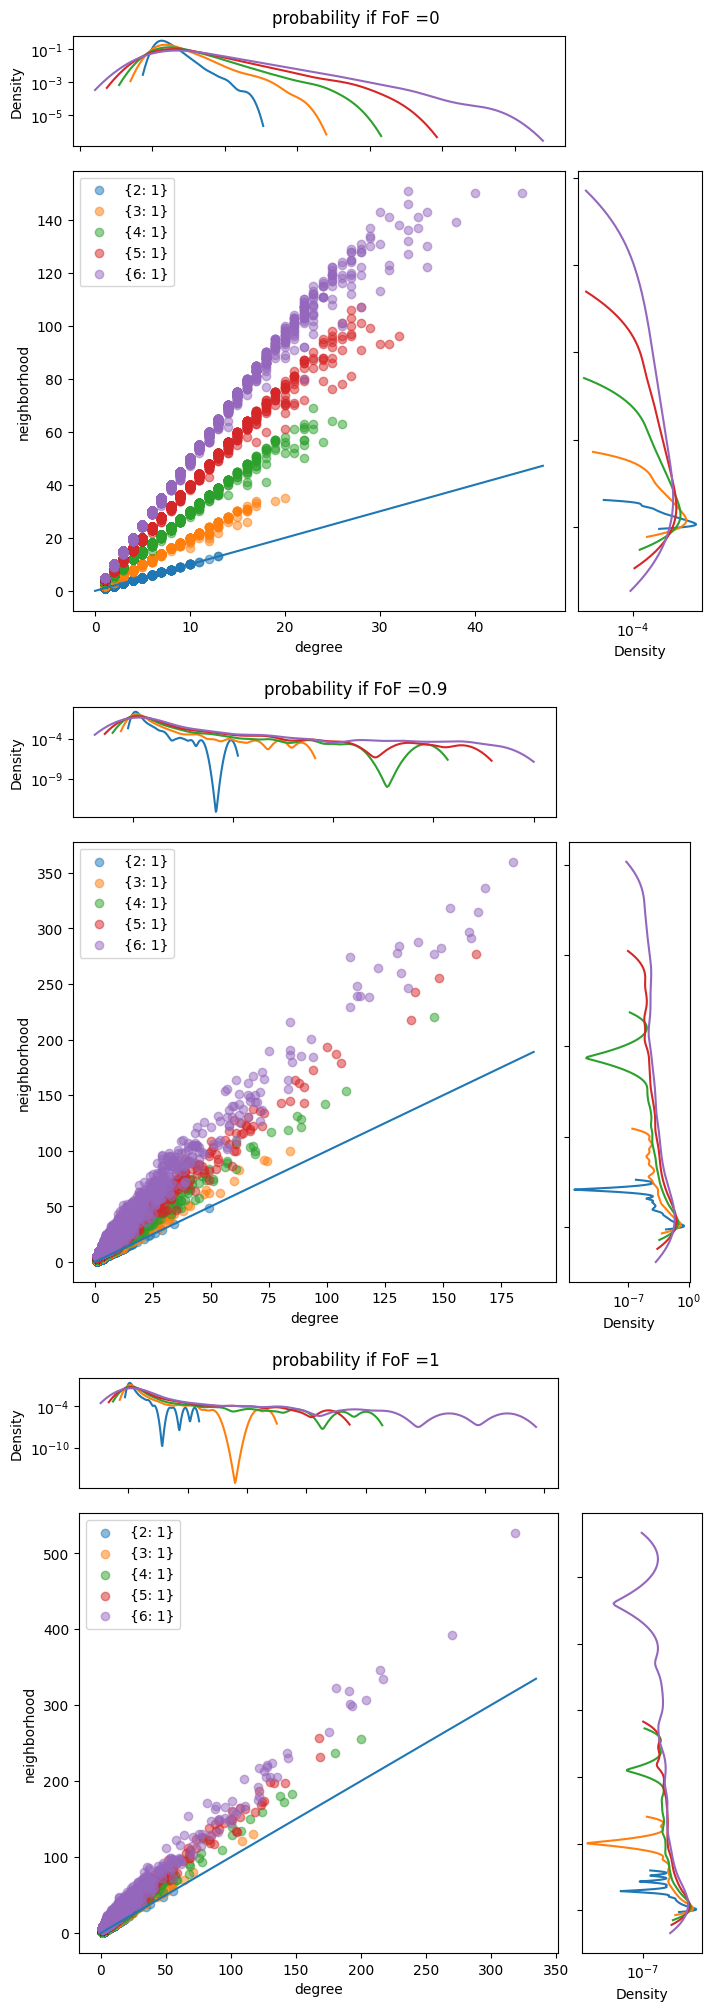

In [ ]:
def scatter_hist(x, y, ax, ax_histx, ax_histy, label):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax.scatter(x, y, label =label, alpha = 0.5)

    sns.kdeplot(x, ax = ax_histx, bw_adjust =3 )
    sns.kdeplot(y =y, ax = ax_histy, bw_adjust =3)

    ax_histx.set_yscale('log')
    ax_histy.set_xscale('log')


n = 5_000

n0 =  20
p = 0
k0 = 1
seed = 10


Ms = [
    {2:7},
    {2:4,3:1},
    {2:1,3:2},
    {2:1,4:1}
]

Ms = [
    {2:1},
    {2:2},
    {2:3},
    {2:7}
]


Ms = [
    {2:1},
    {3:1},
    {4:1},
    {5:1},
    {6:1}
]
ps = [0, 0.9, 1]
fig = plt.figure(figsize=(7,20), layout="constrained")
subfigs = fig.subfigures(nrows=len(ps), ncols=1)  # two big rows

for p, subfig in zip(ps, subfigs):
    axs = subfig.subplot_mosaic([['histx', '.'],
                               ['scatter', 'histy']],
                              width_ratios=(4, 1), height_ratios=(1, 4),
                              )
    for M in Ms:
        H = node_addition_ho_fof(
            n=n,
            M=M,
            p=p, 
            k0 = k0,
            n0 = n0,
            seed = seed)
        x = []
        y = []
        for node in H.nodes:
            gamma = H.nodes.neighbors(node)
            x.append(H.degree(node)) 
            y.append(len(gamma))
        scatter_hist(x, y, axs['scatter'], axs['histx'], axs['histy'], label = M)
        axs['scatter'].legend()
    subfig.suptitle(f'probability if FoF ={p}')
    axs['scatter'].set_xlabel('degree')
    axs['scatter'].set_ylabel('neighborhood')
    #axs['scatter'].set_ylim(0 )
    # plot y=x
    xmax = axs['scatter'].get_xlim()[1]
    axs['scatter'].plot([0, xmax], [0, xmax])
    


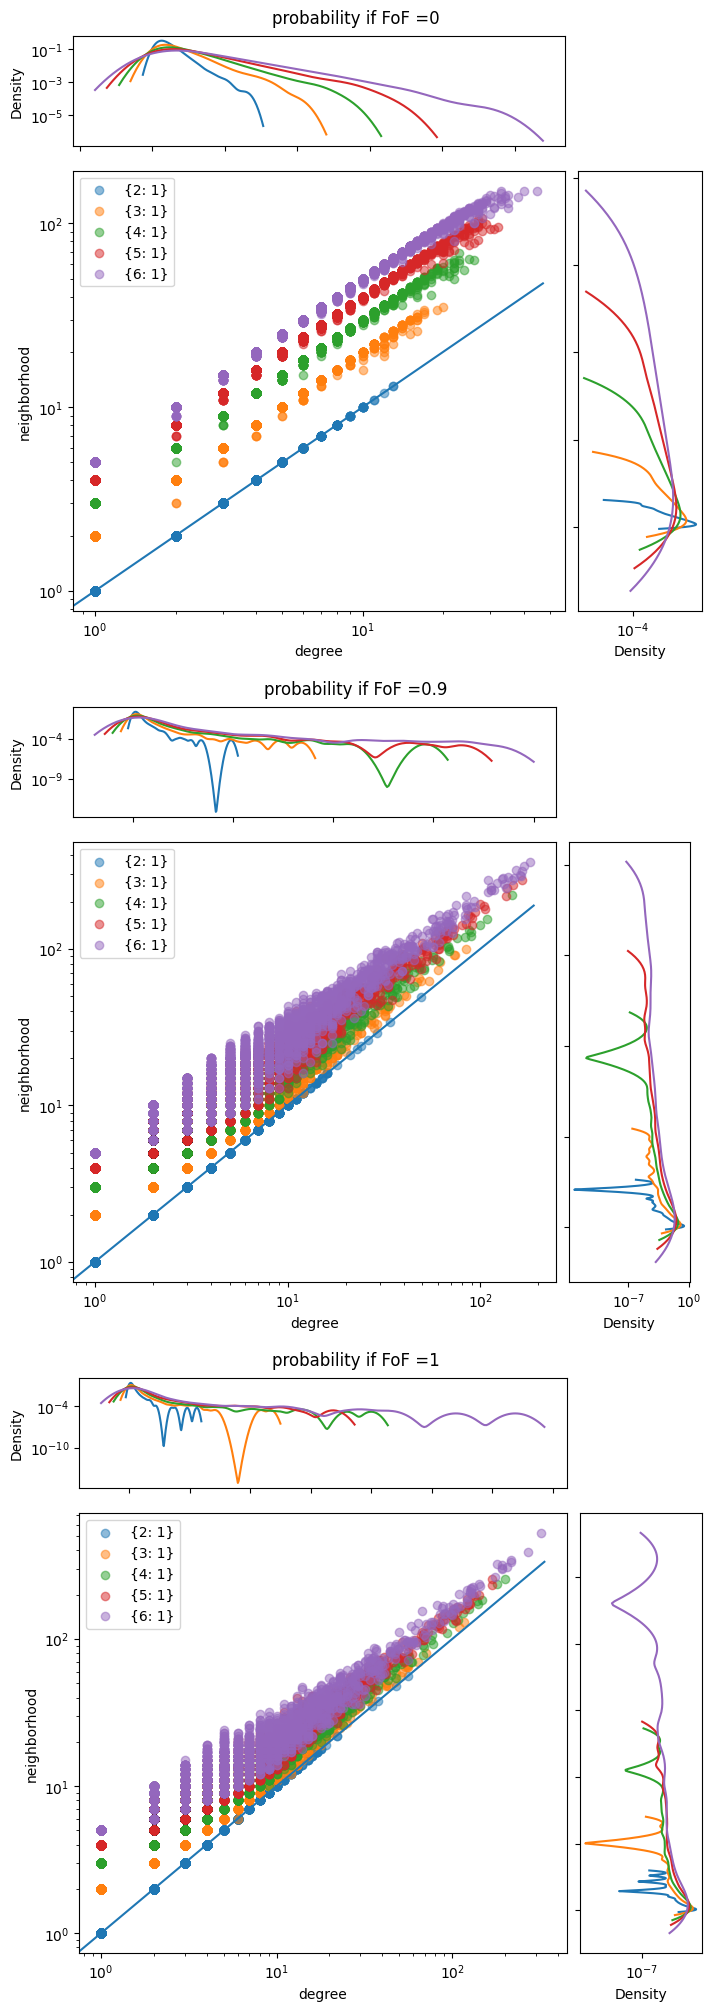

In [ ]:
for subfig in subfigs:
    axs = subfig.axes
    axs[1].set_xscale('log')
    axs[1].set_yscale('log')
    
fig